In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("components.csv")
X = df.drop(columns=["measurement","no","id"]).values

y = df["measurement"].values

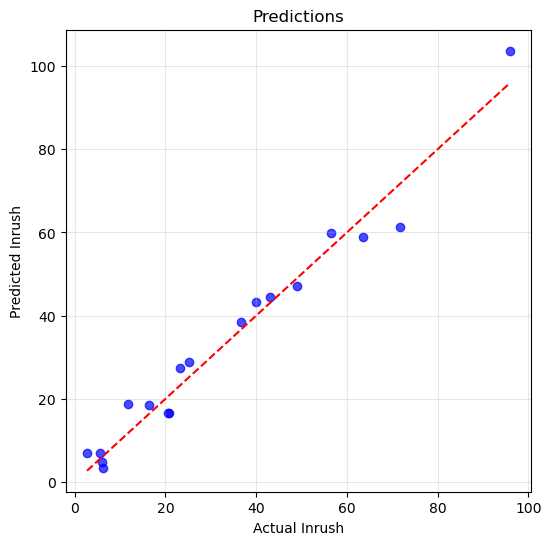

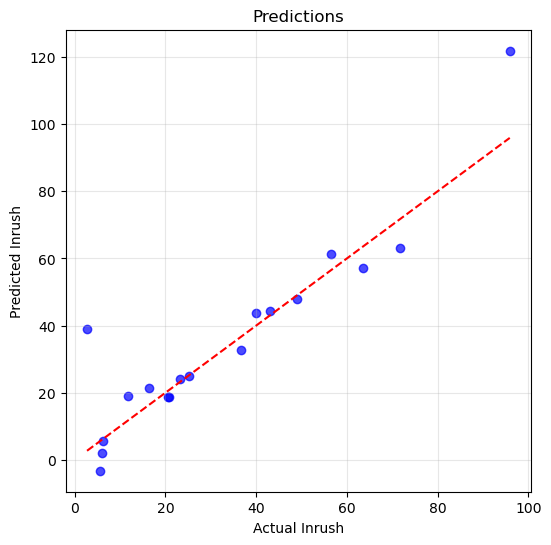

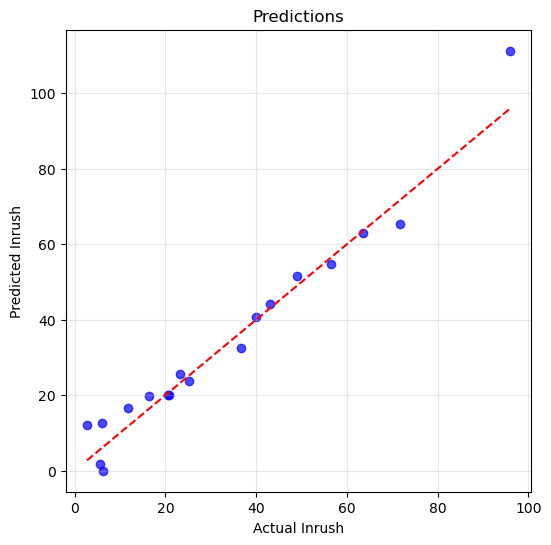

Ridge RMSE: 4.5423672601497875
Lasso RMSE: 11.416949313400826
GPR RMSE: 5.456071342414357
GPR mean predictive std: 3.8134467319797727


In [ ]:
# Leave-One-Out Cross-Validation
loo = LeaveOneOut()

def evaluate_model(model):
    preds = []
    truth = []
    stds = []

    for train_idx, test_idx in loo.split(X):
        model.fit(X[train_idx], y[train_idx])

        # GPR returns uncertainty
        if hasattr(model.named_steps["reg"], "predict"):
            reg = model.named_steps["reg"]
        else:
            reg = model.named_steps["gpr"]

        if isinstance(reg, GaussianProcessRegressor):
            mean, std = model.predict(X[test_idx], return_std=True)
            preds.append(mean[0])
            stds.append(std[0])
        else:
            preds.append(model.predict(X[test_idx])[0])
            stds.append(None)

        truth.append(y[test_idx][0])

    rmse = np.sqrt(mean_squared_error(truth, preds))

    plt.figure(figsize=(6, 6))
    plt.scatter(truth, preds, color="blue", alpha=0.7)
    plt.plot([min(truth), max(truth)], [min(truth), max(truth)], "r--")
    plt.xlabel("Actual Inrush")
    plt.ylabel("Predicted Inrush")
    plt.title("Predictions")
    plt.grid(alpha=0.3)
    plt.show()

    return rmse, stds

# --- Models ---
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=1.0))
])

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Lasso(alpha=0.01, max_iter=10000))
])

kernel = ConstantKernel(1.0, (1e-4, 1e4)) * \
         RBF(length_scale=1.0, length_scale_bounds=(1e-8, 1e4)) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))

gpr = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)) # gpr
])

# --- Evaluate ---
rmse_ridge, _ = evaluate_model(ridge)
rmse_lasso, _ = evaluate_model(lasso)
rmse_gpr, stds_gpr = evaluate_model(gpr)

print("Ridge RMSE:", rmse_ridge)
print("Lasso RMSE:", rmse_lasso)
print("GPR RMSE:", rmse_gpr)
print("GPR mean predictive std:", np.nanmean(stds_gpr))

In [6]:
ridge_model = ridge.named_steps["reg"]
scaler = ridge.named_steps["scaler"]

coef = ridge_model.coef_
feature_names = df.columns[:-1].drop(["no","id"])

#for name, c in zip(feature_names, coef):
#    print(f"{name:20s} {c:+.4f}")

importance = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)

for name, c in importance:
    print(f"{name:20s} {c:+.4f}")



il                   +7.4428
pri_dia              +5.0032
io                   +3.8133
bobbin_width         +3.2092
size                 +2.9799
va                   +1.5316
bmax                 +0.9467
dcr                  +0.8445
coil_height          -0.8165
depth                -0.7147
bobbin_depth         +0.6458
pri                  -0.6407
sec                  -0.3169
pri_turns            +0.2779


In [7]:
print(ridge.named_steps["reg"].coef_)
sum = 0 
for i in ridge.named_steps["reg"].coef_:
    sum += abs(i)

print(sum)
    

[-0.64072574 -0.31690401  1.53163655  0.84449615  2.97994875 -0.71468124
  3.20917749  0.64578603  5.00319033  0.27790675  3.81332777  7.44284753
 -0.81648265  0.94671416]
29.183825161728688


In [8]:
preds = ridge.predict(df.drop(columns=["measurement","no","id"]).values)    

print("Predicted inrush currents for new data:")
#for i, pred in enumerate(preds):
#    print(f"Sample {i+1}: {pred:.2f}")

# for easy copy-paste
for i, pred in enumerate(preds):
    print(f"{pred:.2f} ")


Predicted inrush currents for new data:
5.47 
3.01 
4.65 
5.83 
15.34 
17.38 
17.83 
37.12 
17.83 
26.99 
25.57 
48.56 
43.67 
41.76 
67.90 
61.38 
58.24 
103.69 


In [15]:
#df.drop(columns=["measurement","no","id"]).values

In [10]:
feature_names

Index(['pri', 'sec', 'va', 'dcr', 'size', 'depth', 'bobbin_width',
       'bobbin_depth', 'pri_dia', 'pri_turns', 'io', 'il', 'coil_height',
       'bmax'],
      dtype='object')

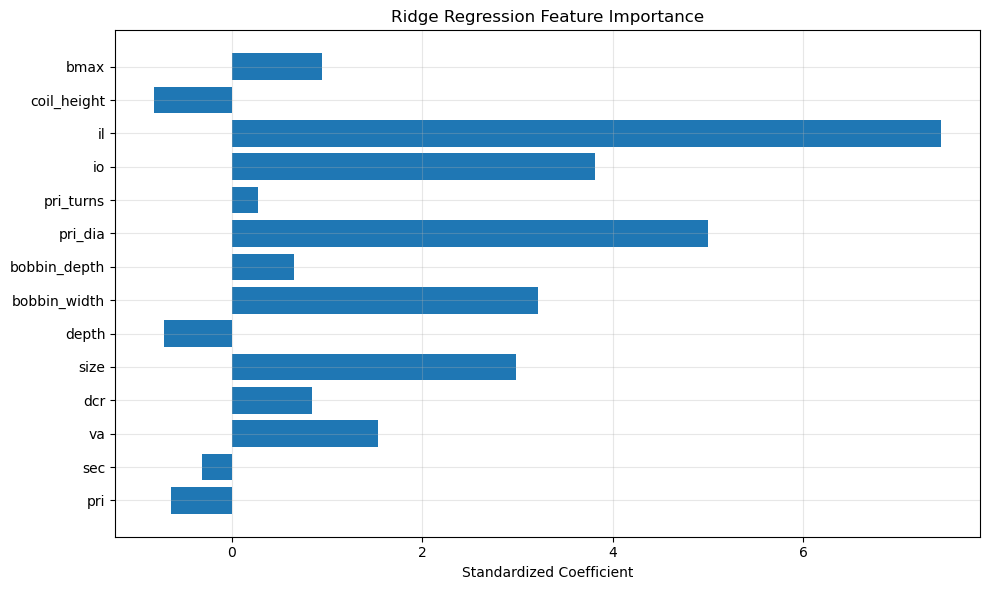

In [11]:
import matplotlib.pyplot as plt
import numpy as np

ridge_model = ridge.named_steps["reg"]
feature_names = df.columns[2:-1]
coef = ridge_model.coef_

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coef)
plt.xlabel("Standardized Coefficient")
plt.title("Ridge Regression Feature Importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


[1.66666667e+02 4.86666667e+01 1.99777778e+02 1.21475000e+01
 9.36111111e+01 4.68333333e+01 3.45500000e+01 5.18055556e+01
 7.07222222e-01 4.84444444e+02 1.11997222e-01 1.23041889e+00
 6.42461111e+00 1.26279640e+00]


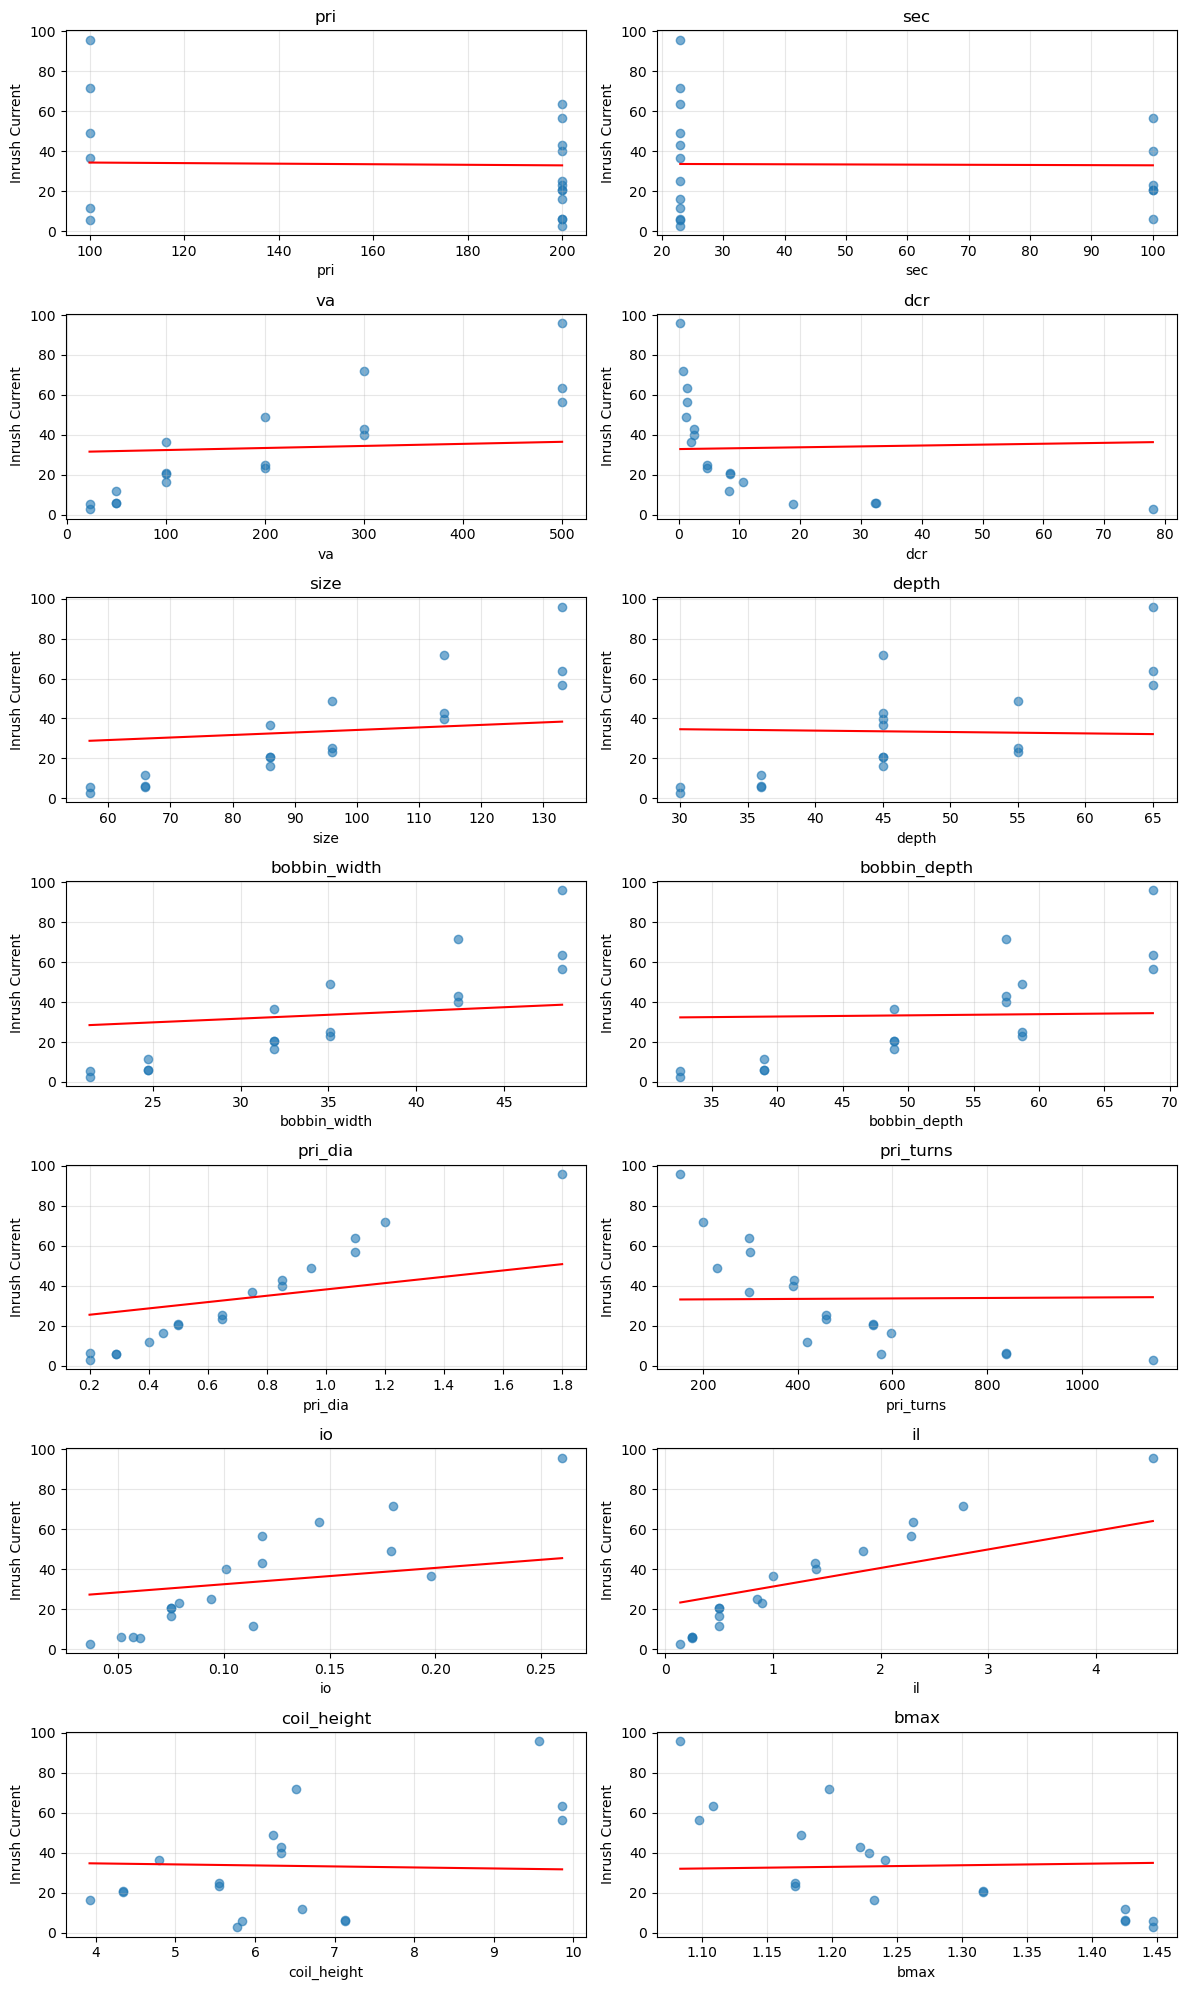

In [13]:
import matplotlib.pyplot as plt
import numpy as np

X_mean = X.mean(axis=0)
print(X_mean)

fig, axes = plt.subplots(7, 2, figsize=(12, 20))
axes = axes.flatten()

for i, ax in enumerate(axes[:len(feature_names)]):
    # vary only feature i
    x_vals = np.linspace(X[:, i].min(), X[:, i].max(), 50)
    X_temp = np.tile(X_mean, (50, 1))
    X_temp
    X_temp[:, i] = x_vals

    y_pred = ridge.predict(X_temp)

    ax.scatter(X[:, i], y, alpha=0.6, label="Actual")
    ax.plot(x_vals, y_pred, color="red", label="Model")
    ax.set_title(feature_names[i])
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Inrush Current")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

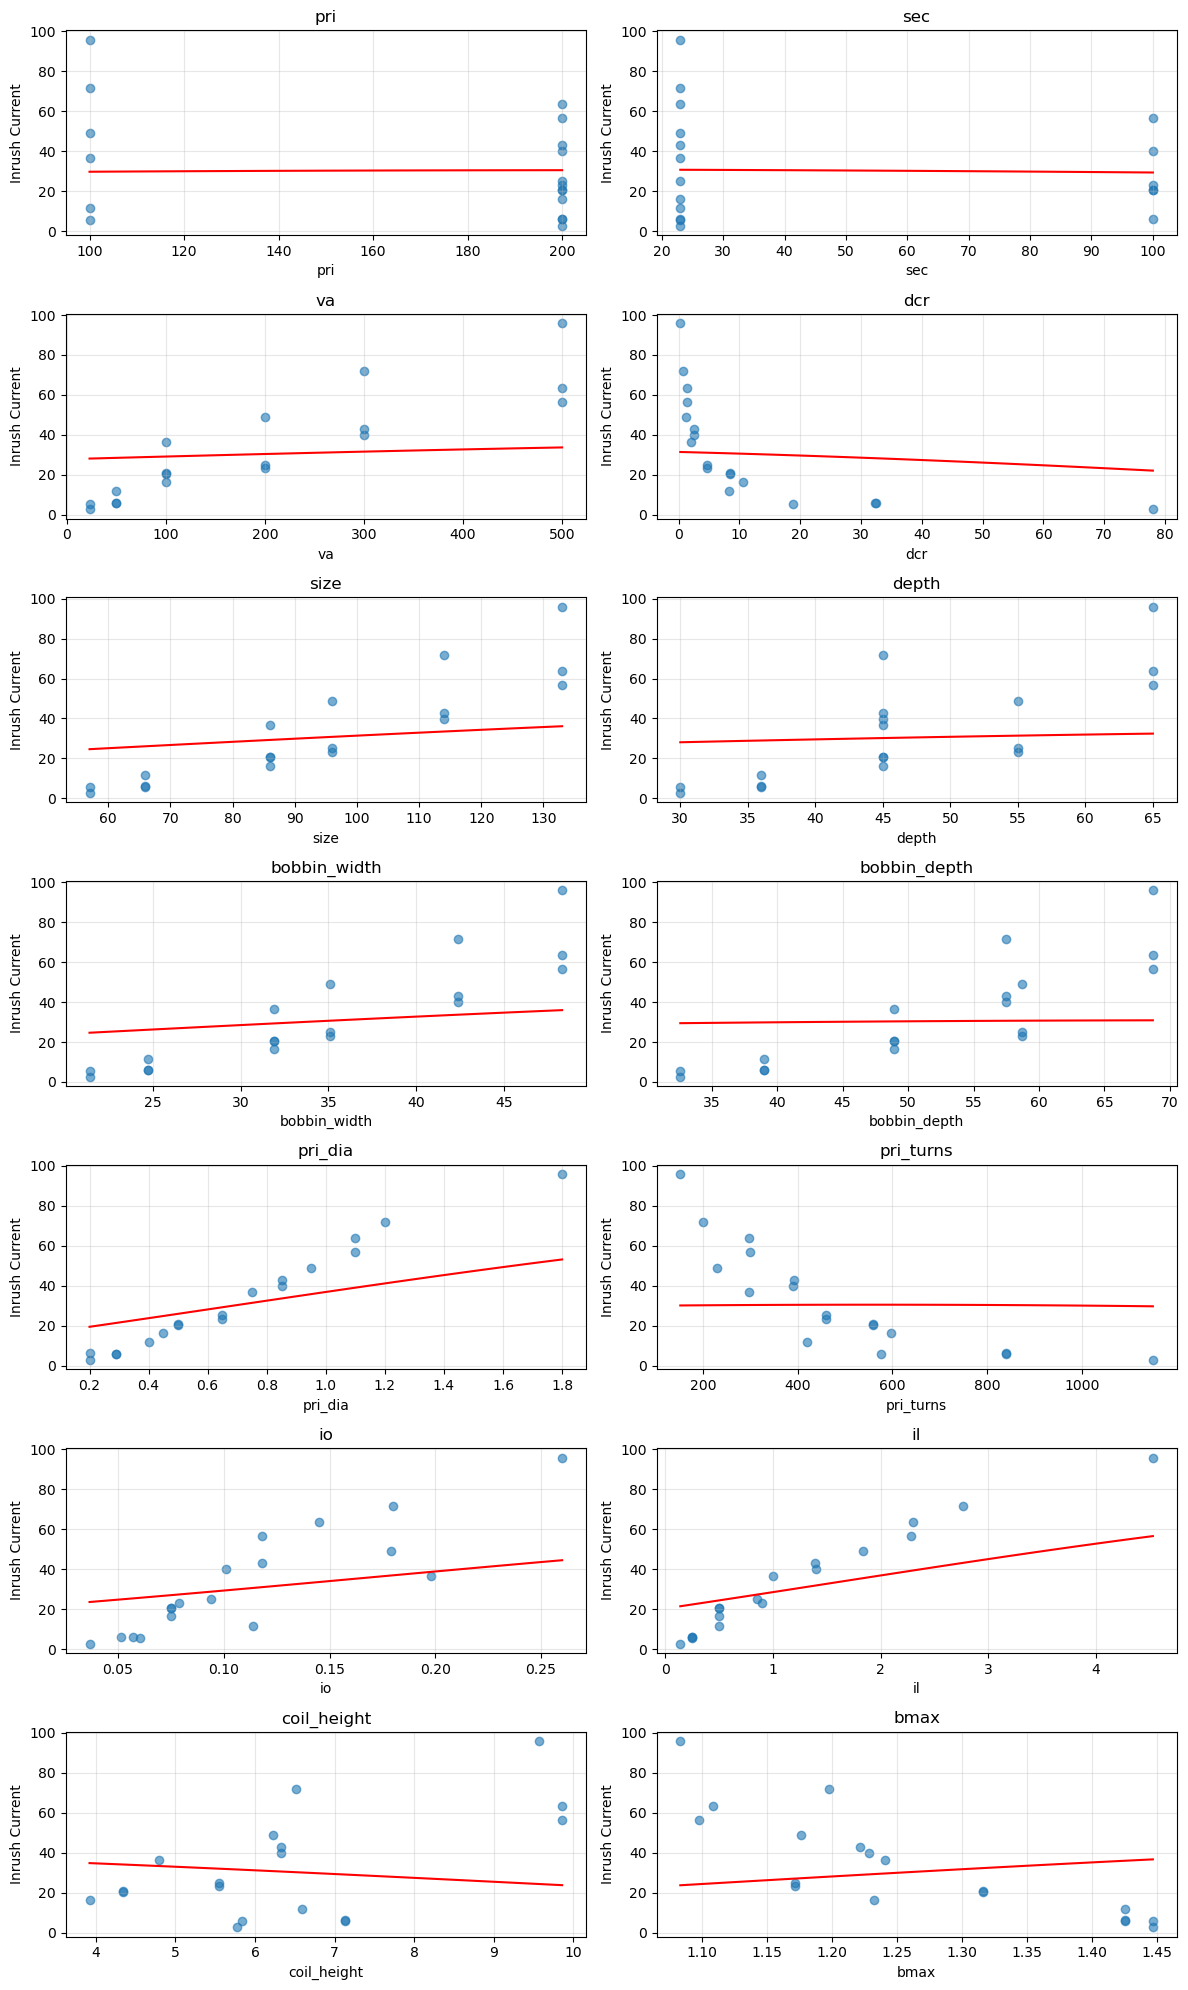

In [14]:
X_mean = X.mean(axis=0)

fig, axes = plt.subplots(7, 2, figsize=(12, 20))
axes = axes.flatten()

for i, ax in enumerate(axes[:len(feature_names)]):
    # vary only feature i
    x_vals = np.linspace(X[:, i].min(), X[:, i].max(), 50)
    X_temp = np.tile(X_mean, (50, 1))
    X_temp[:, i] = x_vals

    y_pred = gpr.predict(X_temp)

    ax.scatter(X[:, i], y, alpha=0.6, label="Actual")
    ax.plot(x_vals, y_pred, color="red", label="Model")
    ax.set_title(feature_names[i])
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Inrush Current")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()